# Assignment 05: Predictive Maintenance from Sensor Logs

## Aim

To classify component failure risk from simulated machine/vehicle sensor logs.

## Input Features

- Temperature
- Vibration
- Pressure
- RPM
- Run Hours

## Target

- 0 = Healthy
- 1 = Failure

## Model

Random Forest Classifier

## Evaluation Metrics

- Precision
- Recall
- F1-score
- Confusion Matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
np.random.seed(42)

n = 800

temp = np.random.normal(
    75,
    10,
    n
)

vibration = np.random.normal(
    2.5,
    1.0,
    n
)

pressure = np.random.normal(
    30,
    5,
    n
)

rpm = np.random.normal(
    3000,
    400,
    n
)

run_hours = np.random.uniform(
    0,
    5000,
    n
)

failure_score = (
    0.04 * (temp - 75)
    + 0.8 * (vibration - 2.5)
    + 0.0006 * run_hours
    + np.random.normal(
        0,
        1,
        n
    )
)

failure = (
    failure_score > 1.2
).astype(int)

sensor_df = pd.DataFrame({
    "temperature_C": temp,
    "vibration_mm_s": vibration,
    "pressure_psi": pressure,
    "rpm": rpm,
    "run_hours": run_hours,
    "failure": failure
})

display(
    sensor_df.head()
)

,temperature_C,vibration_mm_s,pressure_psi,rpm,run_hours,failure
0,79.967142,3.438284,29.085518,2711.304979,4672.165194,1
1,73.617357,1.983955,36.874382,3070.728349,3445.438269,1
2,81.476885,2.596121,26.770179,2781.327966,4116.366063,1
3,90.230299,2.037725,26.004040,2891.337956,2780.953463,1
4,72.658466,2.065504,27.586282,3669.380836,3897.583507,0


In [3]:
print(
    "Failure rate:",
    sensor_df["failure"].mean().round(3)
)

print(
    "\nClass distribution:"
)

print(
    sensor_df["failure"].value_counts()
)

Failure rate: 0.57

Class distribution:
failure
1    456
0    344
Name: count, dtype: int64


In [4]:
X = sensor_df.drop(
    columns=["failure"]
)

y = sensor_df["failure"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 600
Testing samples: 200


In [6]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(
    X_train
)

X_test_s = scaler.transform(
    X_test
)

In [7]:
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

clf.fit(
    X_train_s,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [8]:
preds = clf.predict(
    X_test_s
)

print(
    "Predictions generated successfully."
)

Predictions generated successfully.


In [9]:
print(
    classification_report(
        y_test,
        preds,
        target_names=[
            "Healthy",
            "Failure"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.79      0.80      0.80        86
     Failure       0.85      0.84      0.85       114

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.83      0.82      0.83       200



Confusion Matrix:
[[69 17]
 [18 96]]


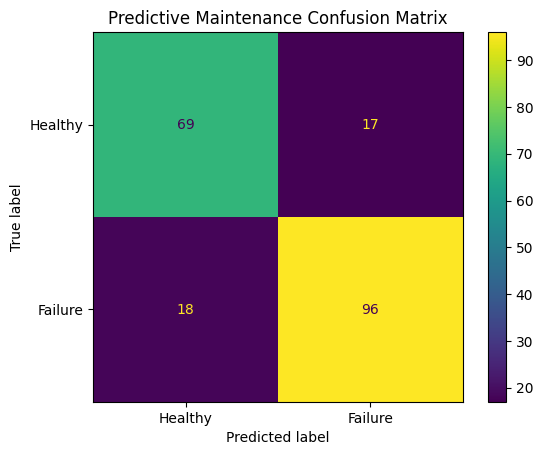

In [10]:
cm = confusion_matrix(
    y_test,
    preds
)

print(
    "Confusion Matrix:"
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Healthy",
        "Failure"
    ]
)

disp.plot()

plt.title(
    "Predictive Maintenance Confusion Matrix"
)

plt.show()

In [11]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance
)

,Feature,Importance
1,vibration_mm_s,0.320921
4,run_hours,0.313667
0,temperature_C,0.144847
3,rpm,0.111466
2,pressure_psi,0.109099


## Result / Conclusion

A Random Forest classifier was successfully trained to predict component failure risk from simulated sensor logs.

Class imbalance was addressed using balanced class weights and stratified train-test splitting.

The model was evaluated using precision, recall, F1-score and a confusion matrix to understand its ability to identify failure cases.